In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc


# Exploratory Data Analysis and Data Understanding

In [2]:
#Loading the dataset into a pandas dataframe
df = pd.read_csv('/content/drive/MyDrive/Datasets/diabetes_binary_health_indicators_BRFSS2015.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

## Dataset Description

The data set used for the task of binary classification in this notebook is the Diabetes Health Indicators dataset. The referenced dataset is the cleaned version of 2015's Behavorial Risk Factor Surveillance System (BRFSS) dataset which is a health related-telephone survery that is collected annually by the CDC (Centers for Disease Control and Prevention), the national public health agency of the United States.

This specific dataset, which is curated from the BRFSS survey to include factors influencing diabetes and other chronic health disesase among the 330 original features, was created by Alex Teboul in 2022.The dataset was accessed from Kaggle by searching for datasets regarding diabetes.

This dataset aligns with the United Nations Sustainable Goal 3 : Good health and Well Being. The CDC estimeates that 1 in 5 diabetics and 8 in 10 prediabetics are unaware of their risk. The study using this dataset which is the study of early diagnosis of diabetes can lead to lifestyle changes which can mitigate the effects or development of diabetes in an individual and, early and better treatment for patients of pre - diabetes. This leads to the improvement of health and overall well being of people around the world.

The features of this dataset are as follows:

* Diabetes_binary(target): 0 = no diabetes, 1 = prediabetes/diabetes
* HighBP (binary): 0 = no high blood pressure, 1 = high blood pressure
* HighChol (binary): 0 = no high cholesterol, 1 = high cholesterol
* CholCheck (binary): 0 = no cholesterol check in 5 years, 1 = cholesterol check in 5 years
* BMI (numeric): Body Mass Index
* Smoker (binary): 0 = no, 1 = yes (smoked at least 100 cigarettes in lifetime)
* Stroke (binary): 0 = no, 1 = yes (ever told had a stroke)
* HeartDiseaseorAttack (binary): 0 = no, 1 = yes (coronary heart disease or myocardial infarction)
* PhysActivity (binary): 0 = no physical activity in past 30 days (excluding job), 1 = yes
* Fruits (binary): 0 = does not consume fruit ≥1 time/day, 1 = consumes fruit ≥1 time/day
* Veggies (binary): 0 = does not consume vegetables ≥1 time/day, 1 = consumes vegetables ≥1 time/day
* HvyAlcoholConsump (binary): 0 = no, 1 = yes (men >14 drinks/week, women >7 drinks/week)
* AnyHealthcare (binary): 0 = no health care coverage, 1 = has health care coverage
* NoDocbcCost (binary): 0 = no, 1 = yes (needed to see doctor but could not see doctor due to cost in past 12 months)
* GenHlth (ordinal): 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor
* MentHlth (numeric): number of days poor mental health (1–30)
* PhysHlth (numeric): number of days poor physical health (1–30)
* DiffWalk (binary): 0 = no difficulty walking/climbing stairs, 1 = serious difficulty
* Sex (binary): 0 = female, 1 = male
* Age (ordinal): 13-level age category
  * 1 = Age 18 to 24
  * 2 = Age 25 to 29
  * 3 = Age 30 to 34
  * 4 = Age 35 to 39
  * 5 = Age 40 to 44
  * 6 = Age 45 to 49
  * 7 = Age 50 to 54
  * 8 = Age 55 to 59
  * 9 = Age 60 to 64
  * 10 = Age 65 to 69
  * 11 = Age 70 to 74
  * 12 = Age 75 to 79
  * 13 = Age 80 or older
* Education (ordinal): 6-level scale
  *   1 = never attended school or only kindergarden
  *   2 = Grades 1 through 8 (Elementary School)

  *   3 = Grade 9 through 11
  *   4 = Grade 12 or GED (High school graduate)

  *   5 = College 1 year to 3 years (Some college or technical school)
  *   6 = College 4 years or more (College Graduate)


* Income (ordinal): 8-level scale:
  * 1 = Less than \$10,000
  * 2 = \$10,000 to less than \$15,000
  * 3 = \$15,000 to less than \$20,000
  * 4 = \$20,000 to less than \$25,000
  * 5 = \$25,000 to less than \$35,000
  * 6 = \$35,000 to less than \$50,000
  * 7 = \$50,000 to less than \$75,000
  * 8 = \$75,000 or more




## Meaningful questions that the dataset can answer



1. Can we use a set of lifestyle factors and medical data/history to accurately predict whether an individual has diabetes?

2. What risk factors are the most influential for diabetes risk prediction?

3. Can the survery questions from survey's such as BRFSS aid in early diagnosis of diabetes in an individual?



## Assessing the dataset quality

The dataset is of high quality, it doesn't have missing values but it does have a number of duplicate rows which have to be dropped. This dataset has extreme class imbalance in the target variable of Diabetes_binary but it is typical in the case of medical datasets like these. It has relavant information on clinical, demographic and lifestyle data reported by people in the BRFSS2015 survey and also whether the people were diabetes positive or not.

## Exploratory Data Analysis

In [3]:
print(df.shape)

(253680, 22)


In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
duplicated_df = df[df.duplicated()]
print(duplicated_df.shape)


(24206, 22)


In [6]:
print(df[df.duplicated()]['Diabetes_binary'].value_counts())

Diabetes_binary
0.0    23957
1.0      249
Name: count, dtype: int64


We can observe from this that most of the duplicated data had "no diabetes" which is better since we are going to drop them, which will lead to better class balance.

In [7]:
# Showing the raw counts and the percentages
print("Class Distribution (Counts):")
print(df['Diabetes_binary'].value_counts())

print("\nClass Distribution (Percentages):")
print(df['Diabetes_binary'].value_counts(normalize=True) * 100)

Class Distribution (Counts):
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Class Distribution (Percentages):
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


In [8]:
df.drop_duplicates(inplace= True)
# Showing the counts and the percentages after dropping duplicates
print("Class Distribution (Counts):")
print(df['Diabetes_binary'].value_counts())

print("\nClass Distribution (Percentages):")
print(df['Diabetes_binary'].value_counts(normalize=True) * 100)

Class Distribution (Counts):
Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64

Class Distribution (Percentages):
Diabetes_binary
0.0    84.705457
1.0    15.294543
Name: proportion, dtype: float64


We can clearly observe that the class imbalance was somewhat improved after dropping duplicate values.

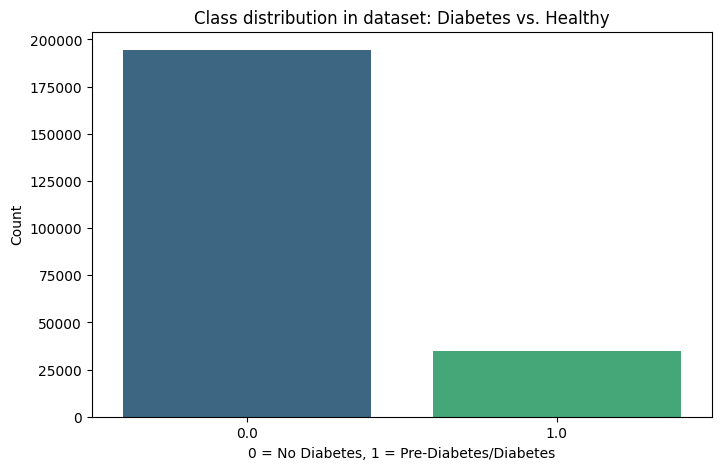

In [9]:
#Visualizing the class distribution of the target variable (Diabetes_Binary)

plt.figure(figsize=(8, 5))
sns.countplot(x='Diabetes_binary', data=df, hue='Diabetes_binary', palette='viridis', legend=False)

plt.title('Class distribution in dataset: Diabetes vs. Healthy')
plt.xlabel('0 = No Diabetes, 1 = Pre-Diabetes/Diabetes')
plt.ylabel('Count')
plt.show()

From the above countplot we can clearly see that there is a huge class imbalance in the target variable of 'Diabetes_binary'. This class imbalance is typical in medical datasets like these since the number of healthy people is almost always higher than the number of people who have chronic diseases. So this class imbalance is to be expected in the diabetes dataset as well.

In [10]:
# Generating the summary statistics for non-binary columns(numeric + ordinal)
non_binary_cols = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

# Generate summary statistics
non_binary_df = df[non_binary_cols]
non_binary_df.describe()

,BMI,GenHlth,MentHlth,PhysHlth,Age,Education,Income
count,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000
mean,28.687507,2.601820,3.509866,4.681219,8.085068,4.979741,5.888615
std,6.789204,1.064962,7.717643,9.050877,3.094451,0.992989,2.092888
min,12.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,24.000000,2.000000,0.000000,0.000000,6.000000,4.000000,4.000000
50%,27.000000,3.000000,0.000000,0.000000,8.000000,5.000000,6.000000
75%,32.000000,3.000000,2.000000,4.000000,10.000000,6.000000,8.000000
max,98.000000,5.000000,30.000000,30.000000,13.000000,6.000000,8.000000


From the summary statistics of the ordinal and numerical columns we can observe that the median BMI is 27 and the mean BMI is 28.68 which indicates that the average person in this dataset is in the 'overweight class(25 to 29) of the BMI chart.It can be also seen that there are people who are severely underweight (with a min value of 12) and also people who are mobidly obese (with a max value of 98).

It can be seen that the median class for age is 8, which represents people who are aged 55 to 59. The median income class is 6 which represents \$35k to \$50k and the median education class is 5 which represents 1 to 3 years of college.

The median class for bad mental and physical health days are both 0 indicating that most people either don't have bad mental or physical health or don't report on it. And finally the median class for general health is 3 which represents good.

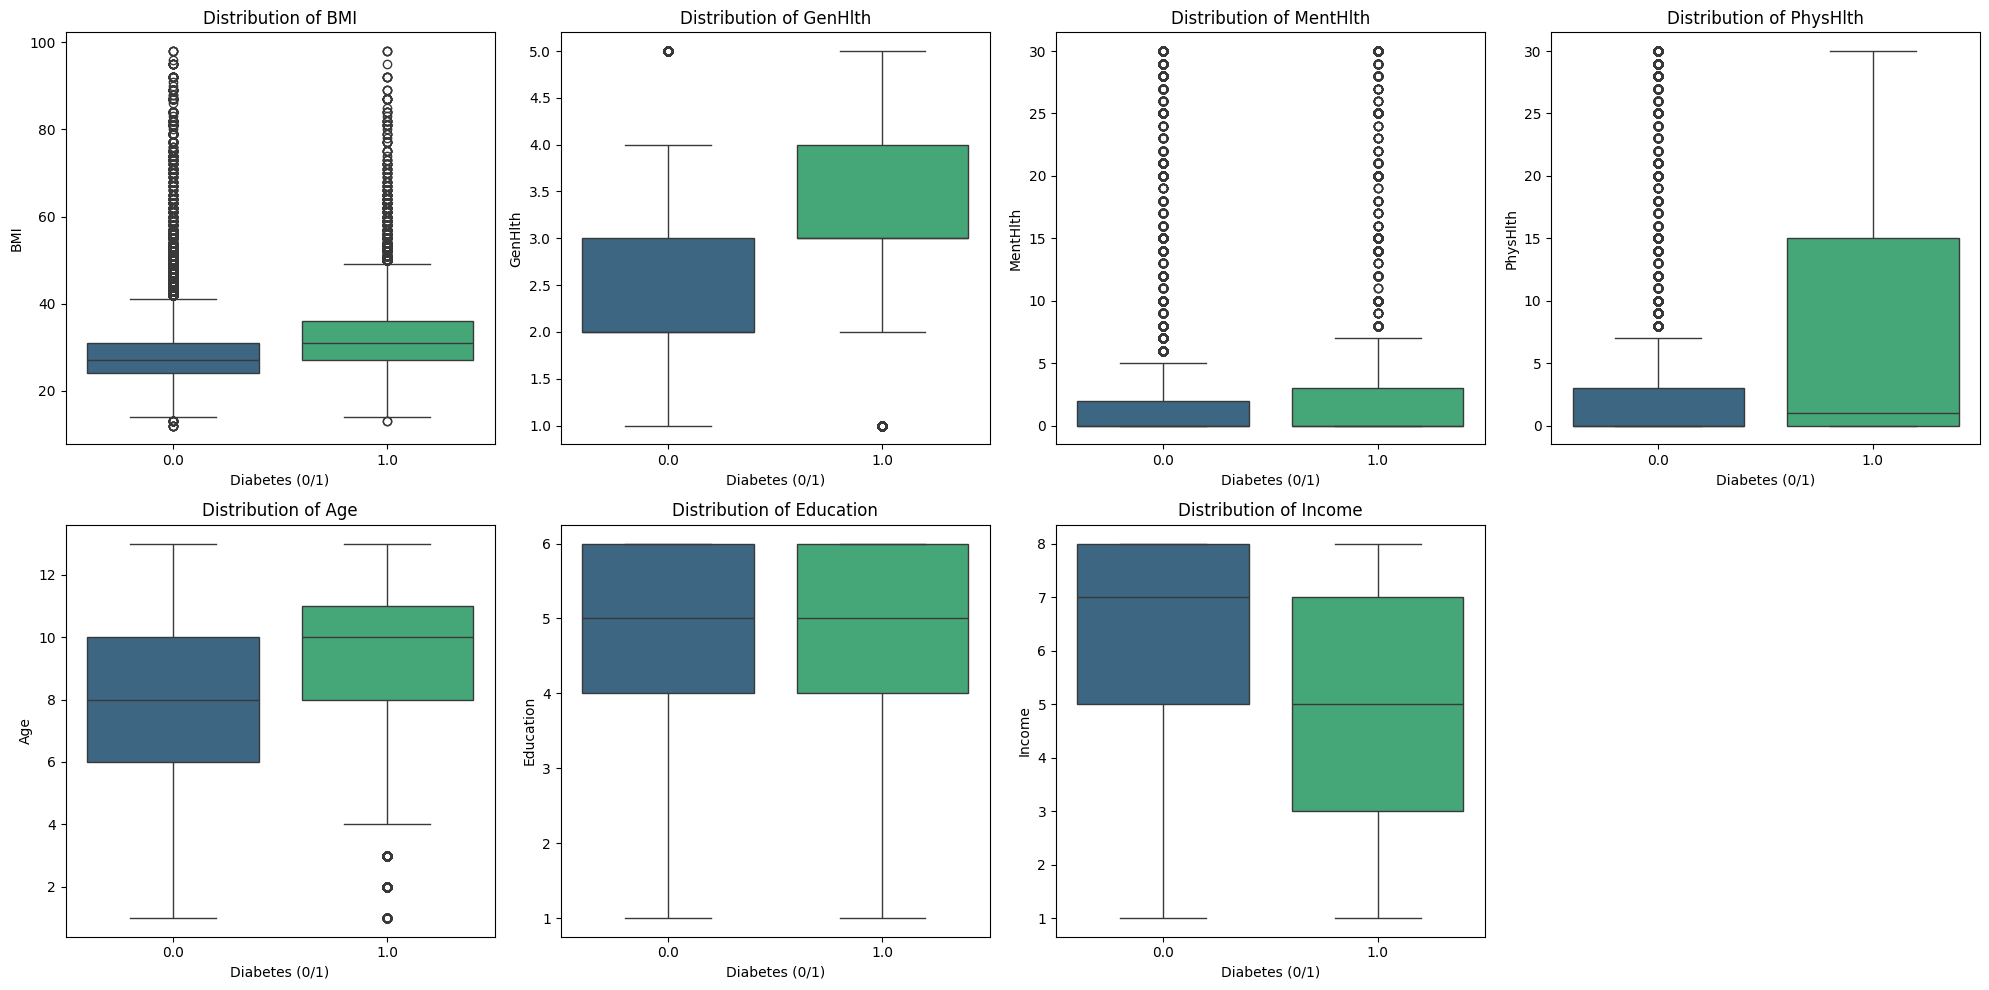

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten() # Flatten to 1D for easy iteration

for i, col in enumerate(non_binary_cols):
    sns.boxplot(x='Diabetes_binary', y=col, data=df, ax=axes[i], palette='viridis', hue='Diabetes_binary', legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Diabetes (0/1)')

# Remove the extra 8th subplot (since we only have 7 columns)
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

From the subplot of the boxplots above, we can see deduce many interpretations.


*   We can see that in the distribution of BMI according to the Diabetes_binary class that the inter-quartile range (IQR) which represents the middle 50% of the data, for diabetes positive people is higher than that of diabetes negative. Meaning that people with diabetes tend to be have a higher BMI than people who don't have diabets. The presence of many outliers in both cases shows that there are a large number of both severely underweight and severely overweight people in both groups (diabetes positive and negative).

*  We can observe from the boxplot of GenHlth column that people who had diabetes reported to have a lower general health status than people who didn't have diabetes, which is expected. (Higher the 'GenHlth' value, poorer the health).

*   We can see from the boxplot for 'MentHlth' which represents the number of days the person reported having poor health in a month, that most people report to have low number of poor mental health days(0 to 4) for both cases. However it should be noted that there are outliers marked by dots for each day number, showing that there are also people in the dataset who reported poorer mental health days from the rest of the population. It can also seen that the IQR of poor mental health days for people who are diabetes positive is only slighly higher, unlike people who reported poorer physical health.

*  We can observe from the box plot for 'PhysHlth' which represents the number of days the person reported having poor physical health in a month, that the people who have diabetes reported to have more number of days of bad physical health which is logical.



*   From the boxplot of age, we can observe that the IQR of age of people who have diabetes is higher than that of people who don't have diabetes, indicating that age can be a risk factor in developing diabetes. The presence of outliers(lower than the lower bound) shows us that while most people who are diabetes positive are of a higher age group, there are also people in age groups 1, 2 and 3 which extends from 18 years to 34 years also have shown to have diabetes.


*   The box plot of education shows that there is similarity in education level in both diabetes positive and negative with the IQR being 4 to 6, which indicates the middle 50 % being atleast Grade 12 graduates.

*  Analysis of the income distribution reveals that the middle 50% of diabetic responders fall into lower income categories than those without diabetes. This different shows the socioeconomic implications often associated with chronic health conditions like diabetes.









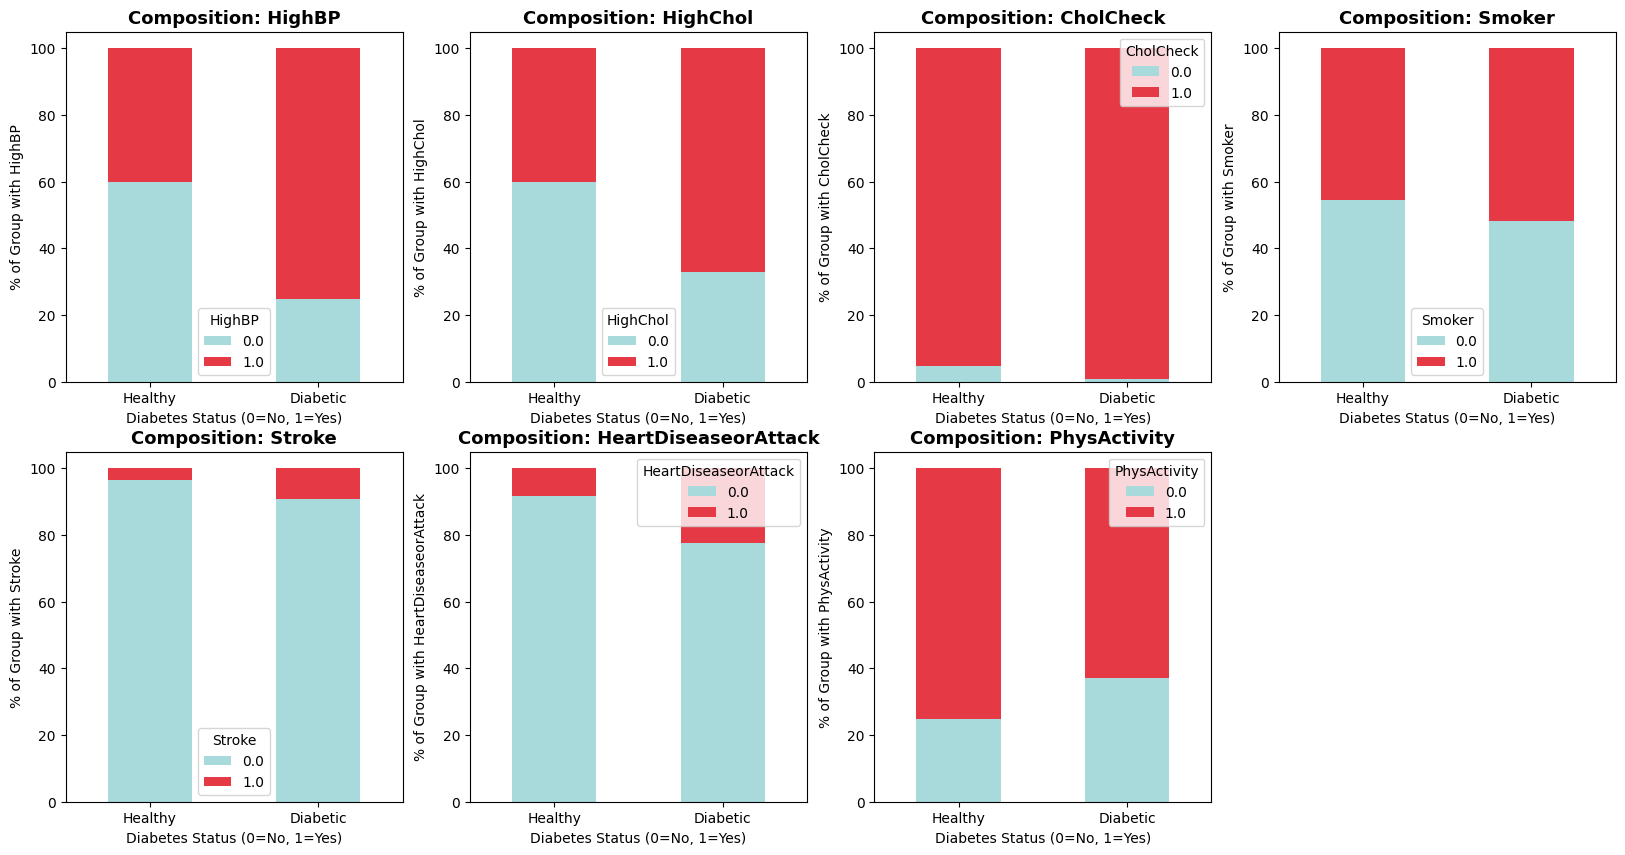

In [12]:
# Group 1: Clinical & Chronic Risk Factors
binary_group_1 = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(binary_group_1):
    ct = pd.crosstab(df['Diabetes_binary'], df[col], normalize='index') * 100

    ct.plot(kind='bar', stacked=True, color=['#A8DADC', '#E63946'], ax=axes[i], legend=True)

    axes[i].set_title(f'Composition: {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Diabetes Status (0=No, 1=Yes)')
    axes[i].set_ylabel(f'% of Group with {col}')
    axes[i].set_xticklabels(['Healthy', 'Diabetic'], rotation=0)

fig.delaxes(axes[7])

From the above cross tabulations of the clinical and chronic risk factors we can make the following deductions:



*   There is a higher percentage of people who reported being diabetes positive that have high blood pressure as well, showing that they are correlated.Same is the case with high colesterol as well.People who reported negative for having diabetes are shown to have less percentage of high blood pressure and high cholesterol. This means that both high blood pressure and high cholesterol can be used as important risk factors for early diagnosis of diabetes.



*   We can also observe that higher percentage of the diabetic population have also had other health complications like a stroke or heart diesease in the past as compared to healthy population, meaning that the occurrence of other health complications such as a stroke or heart attack can also be a predicting factor for diabetes.

*  We can also see that higher percentage of healthy population reported in having engaged in physical activity in the past month than that of diabetic population showing that physical activity can also be a predictor of diabetes.


*  Finally, we can also observe that there is no much difference in compositions of smokers and non smokers in the diabetic and healthy groups, indicating that smoking might not play a huge role in predicting diabetes.







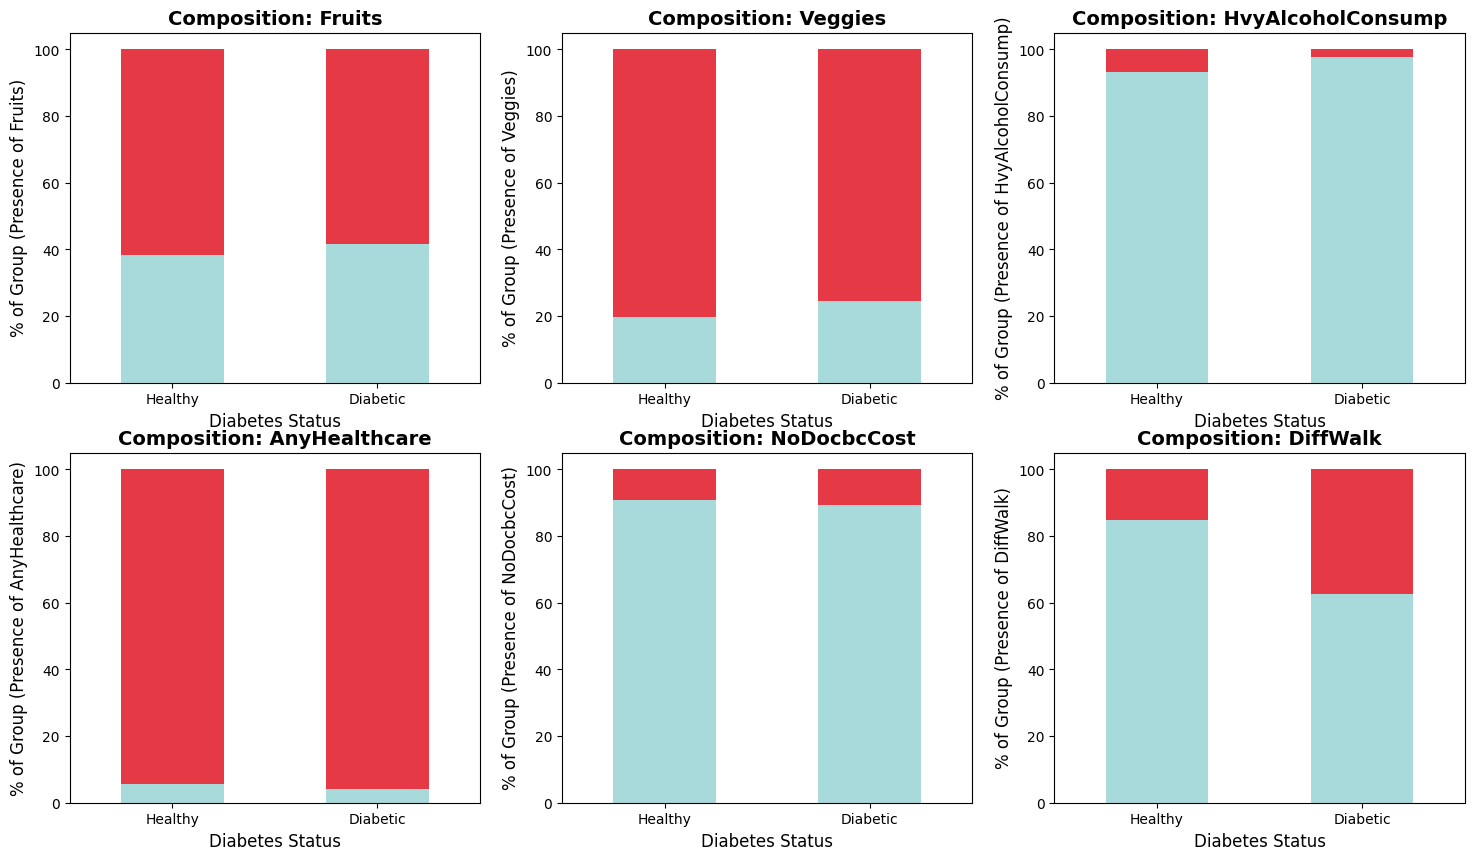

In [13]:
# Group 2: Lifestyle factors and access
binary_group_2 = ['Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(binary_group_2):
    # Cross-tab: Diabetes on X-axis, Lifestyle factor as the colored stacks
    ct = pd.crosstab(df['Diabetes_binary'], df[col], normalize='index') * 100

    # Plotting
    ct.plot(kind='bar', stacked=True, color=['#A8DADC', '#E63946'], ax=axes[i], legend=False)

    # Setting Labels
    axes[i].set_title(f'Composition: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Diabetes Status', fontsize=12)
    axes[i].set_ylabel(f'% of Group (Presence of {col})', fontsize=12)
    axes[i].set_xticklabels(['Healthy', 'Diabetic'], rotation=0)


From the above figure of cross tabulations of lifestyle and access factors we can make the following deductions:


*   We can see that the percentage of people who consume fruits and vegetables atleast once a day is slightly higher in the healthy population than in the diabetic population.
*  We can also observe that percentage of people who have heavy alcohol consumption is comparitively less in the diabetic population. Although rather than being a factor in early diagnosis, this occurence might be the effect of having the condition of diabetes since diabetic people are most often advised not to drink heavy amounts of alcohol which if done can worsen blood sugar control.

* We can also see that higher percentage of diabetic people have difficulty in walking, which is also a complication from having diabetes rather than a predicting factor.

*   Finally we can also observe that access factors such as having healthcare or not or not being able to access a doctors due to costs doesn't differ much in diabetic and healthy population. However, it should be noted that the diabetic population has a higher percentage in both cases, meaning that there could be some correlation between access factors and diabetes too.





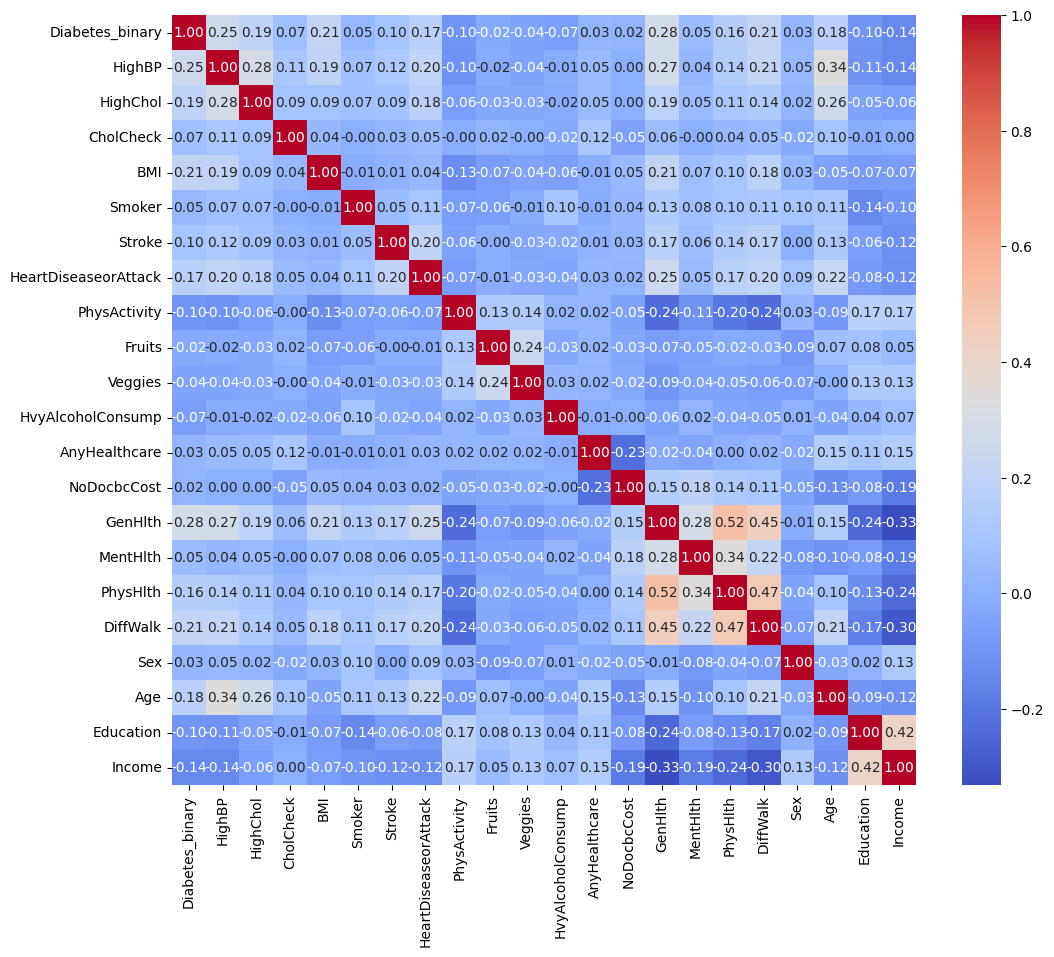

In [14]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [15]:
print(corr_matrix['Diabetes_binary'].sort_values(ascending=False))

Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64


We can observe from the correlation matrix that most features have somewhat of a correaltion with the target variable may it be positive or negative correlation, with clinical factors such as GenHlth, HighBP, HighChol, history of other physical complications like heart attack and stroke having the highest positive correlation whereas lifestyle factors such as eating fruits and vegetables,physical activity and alcohol consumption have a negative correlation with the target variable.

# Building a neural network

In [16]:
#Stratified Sampling (Reducing to 50k rows)
df_sampled, _ = train_test_split(
    df,
    train_size=50000,
    stratify=df['Diabetes_binary'],
    random_state=42
)

In [17]:
# Showing the counts and the percentages after sampling
print("Class Distribution (Counts):")
print(df_sampled['Diabetes_binary'].value_counts())

print("\nClass Distribution (Percentages):")
print(df_sampled['Diabetes_binary'].value_counts(normalize=True) * 100)

Class Distribution (Counts):
Diabetes_binary
0.0    42353
1.0     7647
Name: count, dtype: int64

Class Distribution (Percentages):
Diabetes_binary
0.0    84.706
1.0    15.294
Name: proportion, dtype: float64


In [18]:
X = df_sampled.drop('Diabetes_binary', axis=1)
y = df_sampled['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y #stratified split to maintain the class balance
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to the Training set
sm = SMOTE(random_state=42)
X_train_final, y_train_final = sm.fit_resample(X_train_scaled, y_train)

print(f"Data ready! Training samples: {len(X_train_final)}, Test samples: {len(X_test_scaled)}")

Data ready! Training samples: 67764, Test samples: 10000


In [19]:
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=400,      # Max epochs
    random_state=42,
)
#training on data balanced via SMOTE
mlp.fit(X_train_final, y_train_final)

train_preds = mlp.predict(X_train_final)
test_preds = mlp.predict(X_test_scaled)

In [20]:
def get_metrics(true_labels, predicted_labels, set_name):
    print(f"\n{'='*20} {set_name.upper()} {'='*20}")

    print(classification_report(true_labels, predicted_labels, target_names=['Healthy (0)', 'Diabetic (1)']))
    print('='*50)

get_metrics(y_train_final, train_preds, "Training Set (Balanced)")
get_metrics(y_test, test_preds, "Test Set (Real-World)")


==================== TRAINING SET (BALANCED) ====================
              precision    recall  f1-score   support

 Healthy (0)       0.83      0.79      0.81     33882
Diabetic (1)       0.80      0.84      0.82     33882

    accuracy                           0.81     67764
   macro avg       0.81      0.81      0.81     67764
weighted avg       0.81      0.81      0.81     67764


==================== TEST SET (REAL-WORLD) ====================
              precision    recall  f1-score   support

 Healthy (0)       0.91      0.77      0.83      8471
Diabetic (1)       0.31      0.57      0.40      1529

    accuracy                           0.74     10000
   macro avg       0.61      0.67      0.62     10000
weighted avg       0.82      0.74      0.77     10000



# Baseline Models

## Logistic Regression

In [21]:
log_reg_baseline = LogisticRegression(max_iter=1000, random_state=42)
print("Training Logistic Regression...")
log_reg_baseline.fit(X_train_final, y_train_final)
def evaluate_baseline(model, name, X_train, y_train, X_test, y_test):
    print(f"\n{'#'*20} {name.upper()} {'#'*20}")
    print(f"\n--- TRAINING SET (Balanced) ---")
    print(classification_report(y_train, model.predict(X_train), target_names=['Healthy', 'Diabetic']))

    print(f"\n--- TEST SET (Real-World) ---")
    print(classification_report(y_test, model.predict(X_test), target_names=['Healthy', 'Diabetic']))
    print('='*50)
evaluate_baseline(log_reg_baseline, "Logistic Regression", X_train_final, y_train_final, X_test_scaled, y_test)

Training Logistic Regression...

#################### LOGISTIC REGRESSION ####################

--- TRAINING SET (Balanced) ---
              precision    recall  f1-score   support

     Healthy       0.75      0.71      0.73     33882
    Diabetic       0.73      0.77      0.75     33882

    accuracy                           0.74     67764
   macro avg       0.74      0.74      0.74     67764
weighted avg       0.74      0.74      0.74     67764


--- TEST SET (Real-World) ---
              precision    recall  f1-score   support

     Healthy       0.93      0.72      0.81      8471
    Diabetic       0.31      0.72      0.44      1529

    accuracy                           0.72     10000
   macro avg       0.62      0.72      0.62     10000
weighted avg       0.84      0.72      0.75     10000



## Random Forest Classifier

In [22]:
rf_baseline = RandomForestClassifier(random_state=42)
print("Training Random Forest...")
rf_baseline.fit(X_train_final, y_train_final)
evaluate_baseline(rf_baseline, "Random Forest", X_train_final, y_train_final, X_test_scaled, y_test)

Training Random Forest...

#################### RANDOM FOREST ####################

--- TRAINING SET (Balanced) ---
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00     33882
    Diabetic       1.00      1.00      1.00     33882

    accuracy                           1.00     67764
   macro avg       1.00      1.00      1.00     67764
weighted avg       1.00      1.00      1.00     67764


--- TEST SET (Real-World) ---
              precision    recall  f1-score   support

     Healthy       0.87      0.94      0.90      8471
    Diabetic       0.41      0.24      0.30      1529

    accuracy                           0.83     10000
   macro avg       0.64      0.59      0.60     10000
weighted avg       0.80      0.83      0.81     10000



While the Random Forest has a high overall accuracy, we cannot analyze the test performance of these models on the basis of accuracy because there is a class imbalance of the diabeteic people and non diabetic people in the test set (15/85).

Also while Random forest has higher overall accuracy, it is suffering from extreme overfitting, indicated by 1.00 scores in all of the metrics in the training set.

When analayzing model performance of the test set, we can observe that it failes to identify 74% of the cases, recall value of only (0.24) and an F1-Score of 0.30.

We can observe that Logistic regression is much more reliable as a diagnostic screening tool because it has a high Recall(0.72) and a superior F1-Score of 0.44 which means that it is catching the disease with accuracy better than the untuned Random Forest.

However it is worth to note that Logistic Regression has a lower precision score(0.31) which means that there is a rate of high false positives. THis suggests that while it is better at screening for diabetes, it is more prone to falsely diagnosing healthy individuals than Random Forest(precision of 0.41 for diabetes)


# Hyperparameter Optimization

In [23]:
log_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5,10,15],
    'min_samples_split': [10,20,50]
}


print("Tuning Logistic Regression...")
random_log = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    log_param_grid,
    n_iter=5,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)
random_log.fit(X_train_final, y_train_final)

print("Tuning Random Forest...")
random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    n_iter=10,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)
random_rf.fit(X_train_final, y_train_final)

print(f"\nBest Logistic Regression Params: {random_log.best_params_}")
print(f"Best Random Forest Params: {random_rf.best_params_}")

Tuning Logistic Regression...
Tuning Random Forest...

Best Logistic Regression Params: {'solver': 'liblinear', 'max_iter': 1000, 'C': 0.01}
Best Random Forest Params: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 15}


# Feature Selection

In [24]:
from sklearn.feature_selection import RFE, SelectFromModel


original_feature_names = X_train.columns


print("Performing RFE for Logistic Regression...")
rfe_selector = RFE(estimator=random_log.best_estimator_, n_features_to_select=12, step=1)
rfe_selector.fit(X_train_final, y_train_final)

lr_features = original_feature_names[rfe_selector.support_].tolist()

print("Performing SelectFromModel for Random Forest...")
sfm_selector = SelectFromModel(random_rf.best_estimator_, threshold="mean", prefit=False)
sfm_selector.fit(X_train_final, y_train_final)

# Use the original_feature_names list here too
rf_features = original_feature_names[sfm_selector.get_support()].tolist()

print(f"\nLogistic Regression Features ({len(lr_features)}): {lr_features}")
print(f"Random Forest Features ({len(rf_features)}): {rf_features}")

Performing RFE for Logistic Regression...
Performing SelectFromModel for Random Forest...

Logistic Regression Features (12): ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'Sex', 'Age', 'Income']
Random Forest Features (8): ['HighBP', 'HighChol', 'BMI', 'GenHlth', 'PhysHlth', 'Age', 'Education', 'Income']


# Training final models

In [25]:
# Converting your list of names into a list of number positions (indices)
# We use the index of each name in the original X_train columns
lr_indices = [list(X_train.columns).index(name) for name in lr_features]
rf_indices = [list(X_train.columns).index(name) for name in rf_features]

# Using the INDICES to slice the NumPy array
print("Training Final Logistic Regression...")
final_lr = LogisticRegression(solver='liblinear', max_iter=1000, C=0.01, random_state=42)
final_lr.fit(X_train_final[:, lr_indices], y_train_final)

print("Training Final Random Forest...")
final_rf = RandomForestClassifier(n_estimators=200, min_samples_split=10, max_depth=15, random_state=42)
final_rf.fit(X_train_final[:, rf_indices], y_train_final)

print("Finally! Everything is trained.")

models = {
    'LR Baseline': (LogisticRegression(random_state=42).fit(X_train_final, y_train_final), range(21)),
    'LR Final': (final_lr, lr_indices),
    'RF Baseline': (RandomForestClassifier(random_state=42).fit(X_train_final, y_train_final), range(21)),
    'RF Final': (final_rf, rf_indices)
}

results = []

for name, (model, indices) in models.items():
    X_test_subset = X_test_scaled[:, indices]
    preds = model.predict(X_test_subset)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='binary')
    acc = accuracy_score(y_test, preds)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

df_results = pd.DataFrame(results)
df_results

Training Final Logistic Regression...
Training Final Random Forest...
Finally! Everything is trained.


,Model,Accuracy,Precision,Recall,F1-Score
0,LR Baseline,0.7171,0.314392,0.720078,0.437686
1,LR Final,0.7174,0.315819,0.727273,0.440396
2,RF Baseline,0.8308,0.409745,0.241988,0.304276
3,RF Final,0.8255,0.426330,0.408764,0.417362


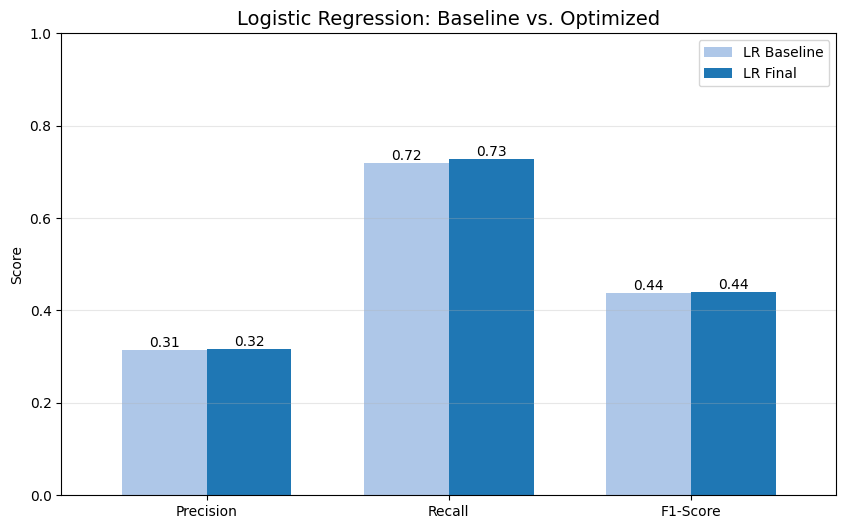

In [26]:
# Filter for LR models
df_lr = df_results[df_results['Model'].str.contains('LR')].set_index('Model')[['Precision', 'Recall', 'F1-Score']].T

ax1 = df_lr.plot(kind='bar', figsize=(10, 6), color=['#aec7e8', '#1f77b4'], width=0.7)
plt.title('Logistic Regression: Baseline vs. Optimized', fontsize=14)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1.0)

for p in ax1.patches:
    ax1.annotate(str(round(p.get_height(), 2)), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

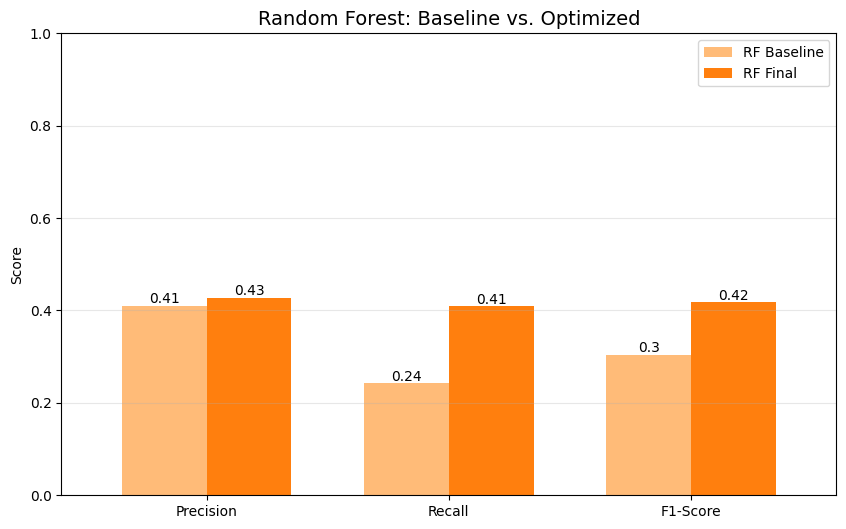

In [27]:
# Filter for RF models
df_rf = df_results[df_results['Model'].str.contains('RF')].set_index('Model')[['Precision', 'Recall', 'F1-Score']].T

ax2 = df_rf.plot(kind='bar', figsize=(10, 6), color=['#ffbb78', '#ff7f0e'], width=0.7)
plt.title('Random Forest: Baseline vs. Optimized', fontsize=14)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1.0)

# Add labels
for p in ax2.patches:
    ax2.annotate(str(round(p.get_height(), 2)), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

[[6062 2409]
 [ 417 1112]]
[[7630  841]
 [ 904  625]]


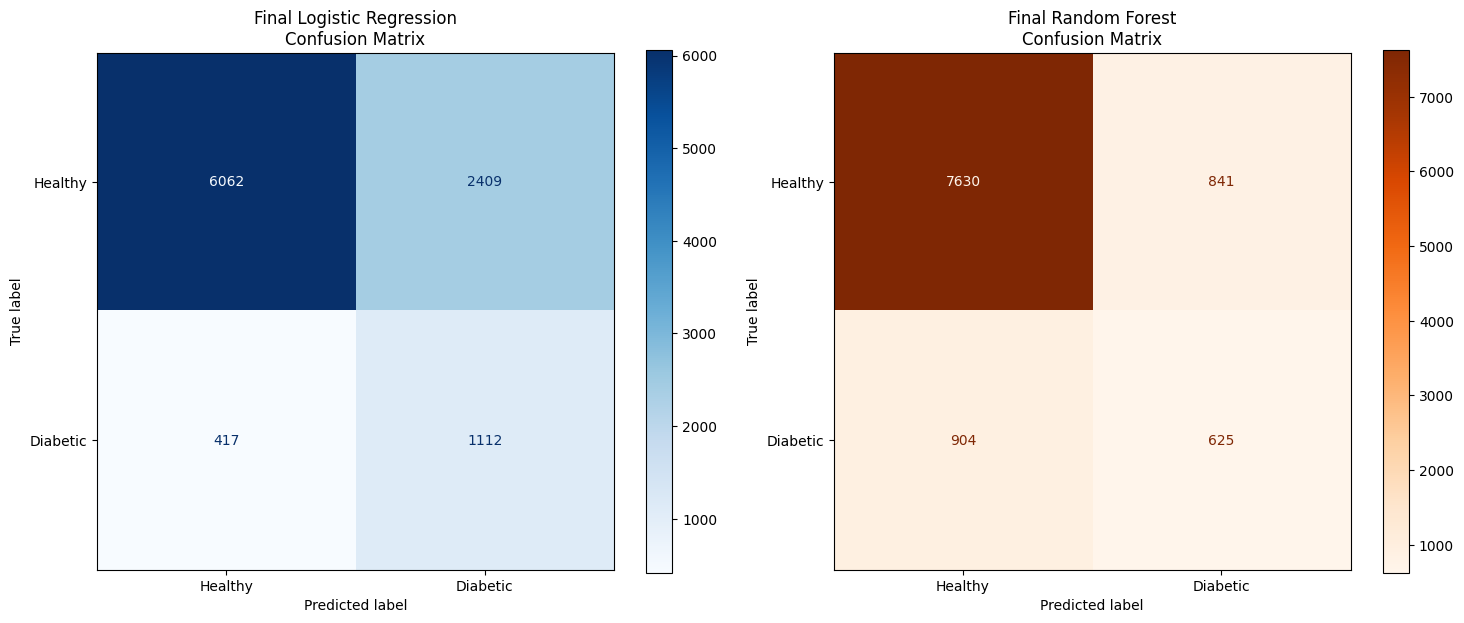

In [28]:
# Getting predictions for both models
X_test_lr = X_test_scaled[:, lr_indices]
X_test_rf = X_test_scaled[:, rf_indices]

lr_preds = final_lr.predict(X_test_lr)
rf_preds = final_rf.predict(X_test_rf)

# Setting up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Logistic Regression Matrix
cm_lr = confusion_matrix(y_test, lr_preds)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Healthy', 'Diabetic'])
disp_lr.plot(cmap='Blues', ax=ax1, values_format='d')
ax1.set_title('Final Logistic Regression\nConfusion Matrix')

# Random Forest Matrix
cm_rf = confusion_matrix(y_test, rf_preds)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Healthy', 'Diabetic'])
disp_rf.plot(cmap='Oranges', ax=ax2, values_format='d')
ax2.set_title('Final Random Forest\nConfusion Matrix')

print(cm_lr)
print(cm_rf)
plt.tight_layout()
plt.show()

This confusion matrix shows us that the final Logistic Regression model was able to identify the actual diabetic people far better than the Final Random Forest model but we can see that it also has a double the number of false positives.

We can see in the confusion matrix of Final Random Forest Classifier that even though it has caught less cases of people who were diabetic, the number of false positives is less.

From this we can see that there is a clear tradeoff between recall and accuracy.

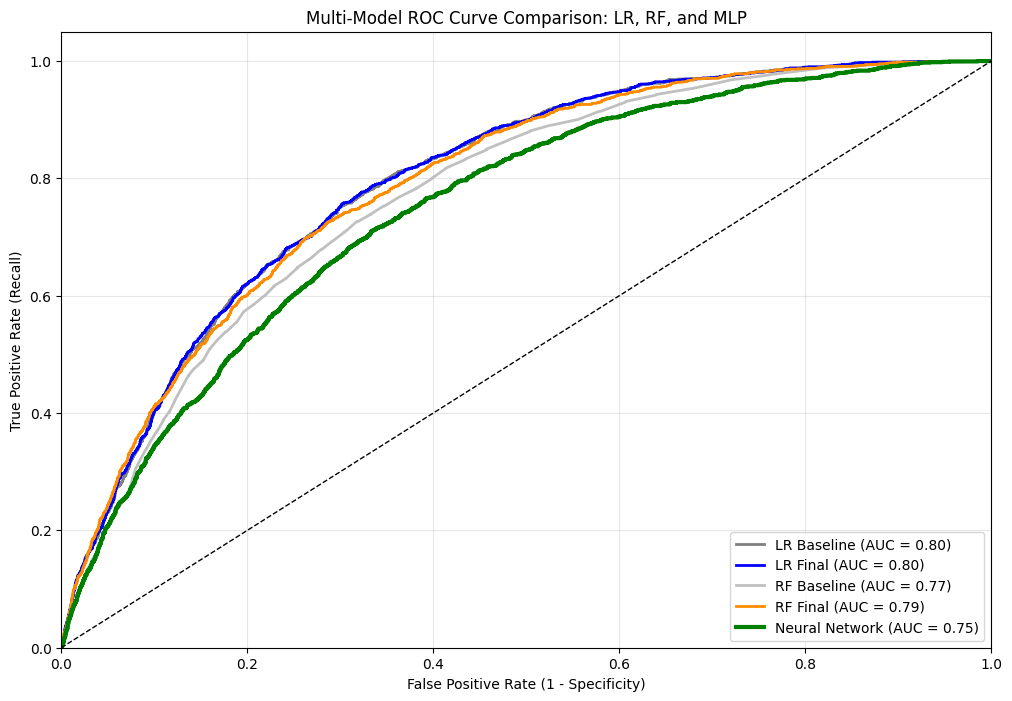

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

nn_probs = mlp.predict_proba(X_test_scaled)[:, 1]

comparison_models = {
    'LR Baseline': (LogisticRegression(random_state=42).fit(X_train_final, y_train_final), range(21)),
    'LR Final': (final_lr, lr_indices),
    'RF Baseline': (RandomForestClassifier(random_state=42).fit(X_train_final, y_train_final), range(21)),
    'RF Final': (final_rf, rf_indices)
}

plt.figure(figsize=(12, 8))

colors = ['gray', 'blue', 'silver', 'darkorange']
for (name, (model, indices)), color in zip(comparison_models.items(), colors):
    # Predicting probabilities for the relevant feature subset
    probs = model.predict_proba(X_test_scaled[:, indices])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')


fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_probs)
auc_nn = auc(fpr_nn, tpr_nn)
plt.plot(fpr_nn, tpr_nn, color='green', lw=3, label=f'Neural Network (AUC = {auc_nn:.2f})')

plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Multi-Model ROC Curve Comparison: LR, RF, and MLP')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

From the AUC-ROC curve we can see that the Logistic Regression models (baseline and final) are the best performing ones with the highest AUC of approximately 0.80, which indicates that they are better at correctly ranking positive cases higher than negative ones compared to other models.

The Random Forest models follow behid the Logistic regression ones with AUC values around 0.77-0.79 which show acceptable performance but slightly weaker class seperation.

The Neural Network model has the lowest AUC at approximately 0.75 which indicates comparitively lower predictive capability.

Overall the Logistic regression demonstrates the strongest ability to differentiate between the target classes in this dataset.